In [15]:
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd
import yaml

from src.tools.presets import get_list_of_presets
from src.tools.read.rerank.load_rerank import load_analyze_retrieval_dataframes


load_dotenv()

ANALYZE_RETRIEVAL_DIR = Path(os.getenv("ANALYZE_RETRIEVAL_DIR"))

with open("params.yaml", "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

datasets_cfg = params.get("preprocess_datasets").get("datasets")
if not datasets_cfg:
    raise ValueError("Nie znaleziono datasets_download w params.yaml")

chunking_cfg = params.get("chunking").get("methods")
if not chunking_cfg:
    raise ValueError("Nie znaleziono chunking_methods w params.yaml")

embed_cfg = params.get("vector_embed").get("methods")
if not embed_cfg:
    raise ValueError("Nie znaleziono vector_embed_methods w params.yaml")

search_cfg = params.get("search").get("methods")
if not embed_cfg:
    raise ValueError("Nie znaleziono search methods w params.yaml")

rerank_cfg = params.get("rerank").get("methods")
if not embed_cfg:
    raise ValueError("Nie znaleziono rerank methods w params.yaml")

analyze_cfg = params.get("analyze_retrieval").get("methods")
if not analyze_cfg:
    raise ValueError("Nie znaleziono analyze_retrieval_methods w params.yaml")

splits = params.get("chunking").get("splits")
if not splits:
    raise ValueError("Nie znaleziono splits w params.yaml")

dataset_names, dataset_params_names = get_list_of_presets(datasets_cfg)
chunking_names, chunking_params_names = get_list_of_presets(chunking_cfg)
embed_names, embed_params_names = get_list_of_presets(embed_cfg)
search_names, search_params_names = get_list_of_presets(search_cfg)
rerank_names, rerank_params_names = get_list_of_presets(rerank_cfg)
analyze_retrieval_names, analyze_retrieval_params_names = get_list_of_presets(analyze_cfg)

configs = []
for dataset, dataset_params in zip(dataset_names, dataset_params_names):
    for chunking, chunking_params in zip(chunking_names, chunking_params_names):
        for embed, embed_params in zip(embed_names, embed_params_names):
            if 'local' in embed_params:
                continue
            for search, search_params in zip(search_names, search_params_names):
                for rerank, rerank_params in zip(rerank_names, rerank_params_names):
                    for analyze, analyze_params in zip(analyze_retrieval_names, analyze_retrieval_params_names):
                            for split in splits:
                                configs.append({
                                    "dataset_name": dataset,
                                    "dataset_params_name": dataset_params,
                                    "chunking_name": chunking,
                                    "chunking_params_name": chunking_params,
                                    "embed_name": embed,
                                    "embed_params_name": embed_params,
                                    "search_name": search,
                                    "search_params_name": search_params,
                                    "rerank_name": rerank,
                                    "rerank_params_name": rerank_params,
                                    "analyze_retrieval_name": analyze,
                                    "analyze_retrieval_params_name": analyze_params,
                                    "split_name": split
                                })
retrieval_df = load_analyze_retrieval_dataframes(ANALYZE_RETRIEVAL_DIR, configs)
# acc_cols = pd.DataFrame(
#     retrieval_df["Accuracy@1-5"].tolist(),
#     index=retrieval_df.index
# )

# acc_cols.columns = [f"Accuracy@{i+1}" for i in range(acc_cols.shape[1])]

# # usuń starą listę + stare accuracy kolumny
# cols_to_drop = ["Accuracy@1-5"] + [c for c in retrieval_df.columns if c.startswith("Accuracy@")]

# retrieval_df = retrieval_df.drop(columns=cols_to_drop).join(acc_cols)

metric_cols = [
    "Accuracy@1",
    "Accuracy@2",
    "Accuracy@3",
    "Accuracy@4",
    "Accuracy@5",
    "Recall@10",
    "MRR@10",
    "NDCG@10",
    "rerank_result_time",
]

# reszta kolumn
other_cols = [c for c in retrieval_df.columns if c not in metric_cols]

metric_cols = [
    "Accuracy@1",
    "Accuracy@2",
    "Accuracy@3",
    "Accuracy@4",
    "Accuracy@5",
    "Recall@10",
    "MRR@10",
    "NDCG@10",
    "rerank_result_time",
]

# reszta kolumn
other_cols = [c for c in retrieval_df.columns if c not in metric_cols]
retrieval_df

rerank_result_time  \
dataset_name        dataset_params_name chunking_name chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name analyze_retrieval_name analyze_retrieval_params_name split_name                       
infiniteBenchChoice default             fixed_size    norm_token           FAISS      default_global    faiss       default_top20      reranker    default_top5       analyze_retrieval      default                       example               3.544376   
                                        recursive     norm                 FAISS      default_global    faiss       default_top20      reranker    default_top5       analyze_retrieval      default                       example               1.511879   

                                                                                                                                                                                                                                       Accuracy@1  \
dataset_name        dataset_params_name chunking_name chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name analyze_retrieval_name analyze_retrieval_params_name split_name               
infiniteBenchChoice default             fixed_size    norm_token           FAISS      default_global    faiss       default_top20      reranker    default_top5       analyze_retrieval      default                       example            1.0   
                                        recursive     norm                 FAISS      default_global    faiss       default_top20      reranker    default_top5       analyze_retrieval      default                       example            1.0   

                                                                                                                                                                                                                                       Accuracy@2  \
dataset_name        dataset_params_name chunking_name chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name analyze_retrieval_name analyze_retrieval_params_name split_name               
infiniteBenchChoice default             fixed_size    norm_token           FAISS      default_global    faiss       default_top20      reranker    default_top5       analyze_retrieval      default                       example            1.0   
                                        recursive     norm                 FAISS      default_global    faiss       default_top20      reranker    default_top5       analyze_retrieval      default                       example            1.0   

                                                                                                                                                                                                                                       Accuracy@3  \
dataset_name        dataset_params_name chunking_name chunking_params_name embed_name embed_params_name search_name search_params_name rerank_name rerank_params_name analyze_retrieval_name analyze_retrieval_params_name split_name               
infiniteBenchChoice default             fixed_size    norm_token           FAISS      default_global    faiss       default_top20      reranker    default_top5       analyze_retrieval      default                       example            1.0   
                                        recursive     norm                 FAISS      default_global    faiss       default_top20      reranker    default_top5       analyze_retrieval      default                       example            1.0   

                                                                                                                                                                                                                                       Accuracy@4  \
dataset_name        dataset_pa

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import math


def plot_metrics_subplots(df, metric_cols, ncols=2):

    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    n_metrics = len(metric_cols)
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4 * nrows),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    x = np.arange(len(df))

    # kolory automatyczne z matplotlib
    colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

    for ax, metric in zip(axes, metric_cols):

        for i, (label, color) in enumerate(zip(labels, colors)):
            ax.bar(
                i,
                df.iloc[i][metric],
                color=color,
                label=label if metric == metric_cols[0] else None
            )

        ax.set_title(metric)
        ax.set_ylim(0, 1)

        # ukryj x ticki
        ax.set_xticks([])

    # usuń puste subploty
    for ax in axes[n_metrics:]:
        fig.delaxes(ax)

    # wspólna legenda
    fig.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    return fig, axes

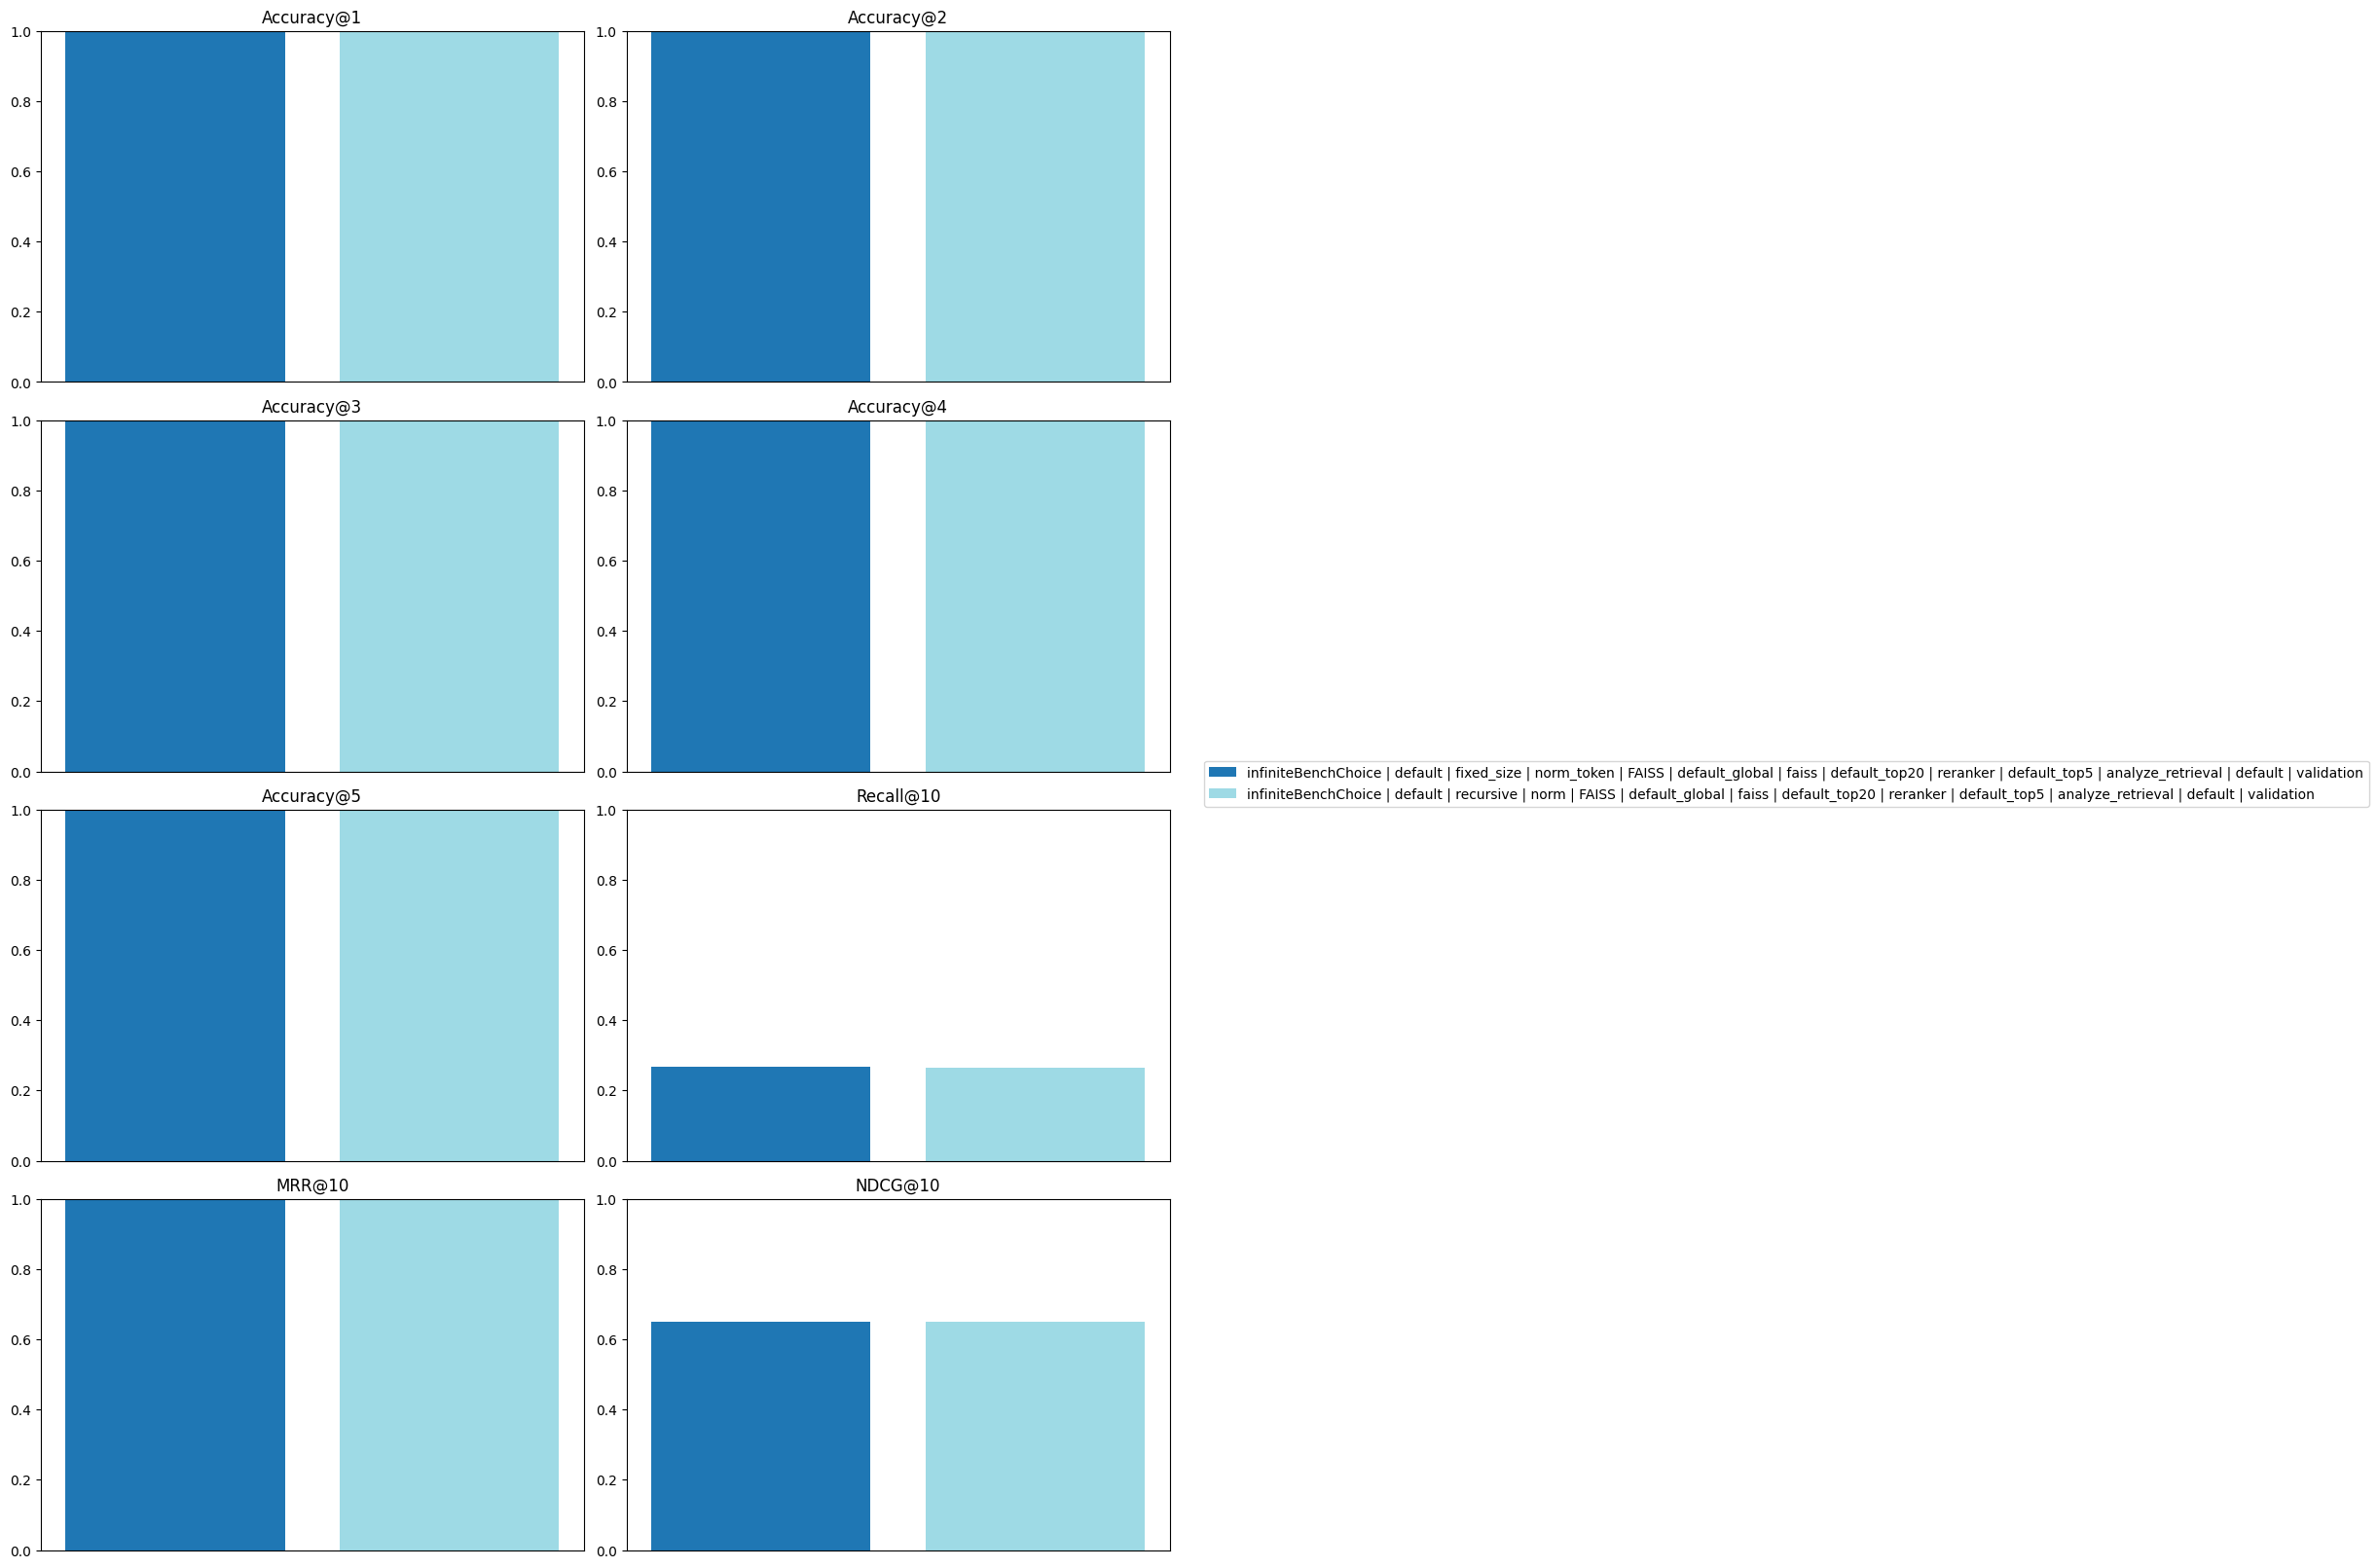

In [10]:
metric_cols = [
    "Accuracy@1",
    "Accuracy@2",
    "Accuracy@3",
    "Accuracy@4",
    "Accuracy@5",
    "Recall@10",
    "MRR@10",
    "NDCG@10",
]

fig, axes = plot_metrics_subplots(retrieval_df, metric_cols)
plt.show()

In [11]:
from matplotlib import pyplot as plt


def plot_time(df, time_column_name):
    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    fig, ax = plt.subplots(figsize=(14, 5))

    x = range(len(df))

    ax.bar(x, df[time_column_name])

    ax.set_title(time_column_name)
    ax.set_ylabel("time [s]")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)

    return fig, ax

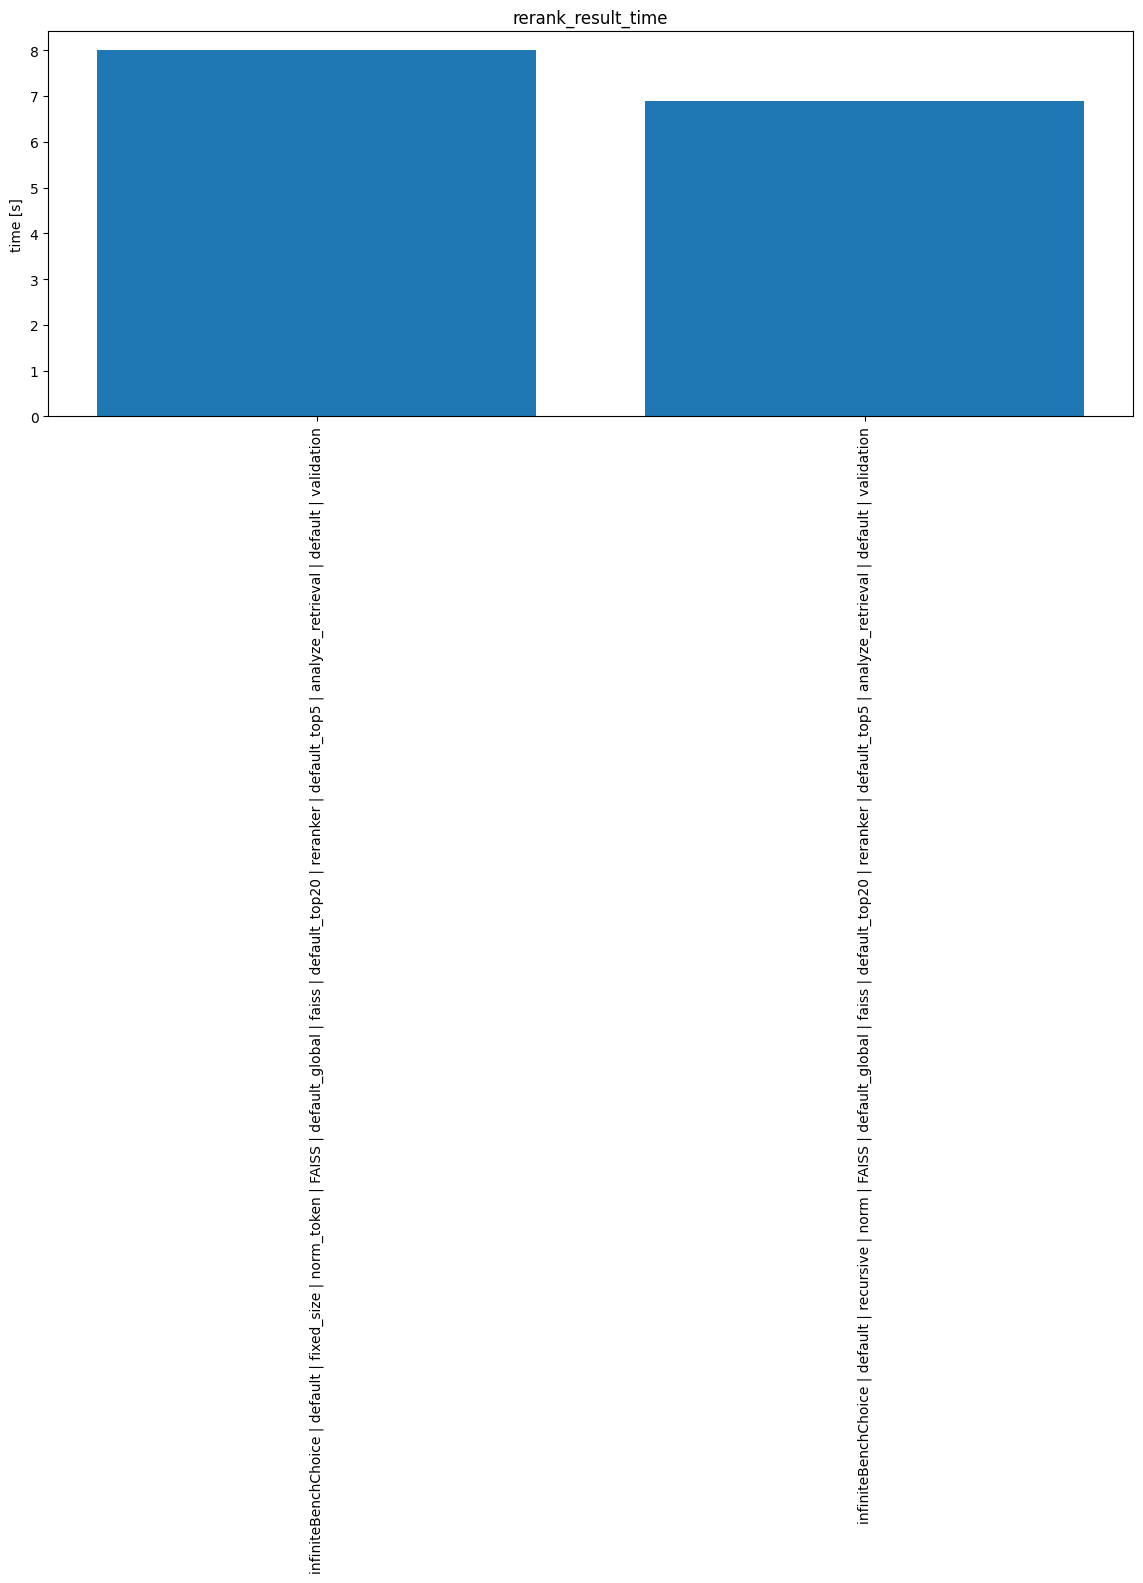

In [12]:
fig, ax = plot_time(retrieval_df, 'rerank_result_time')
plt.show()